# 1. Загрузка и первичный разведочный анализ

In [1]:
import pandas as pd
import numpy as np


dataSet = pd.read_csv('ai_student_impact_dataset.csv')

dataSet.info()
print(dataSet.isnull().sum())
# display(dataSet.head(35))
dataSet.describe()

categorical_cols = dataSet.select_dtypes(include=['str', 'category']).columns
print(f"Кол-во уникальных значений:\n{dataSet[categorical_cols].nunique()}")

for cat_col in categorical_cols:
  print(f"Уникальные значения для {cat_col}:\n{dataSet[cat_col].unique()}\n")

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           50000 non-null

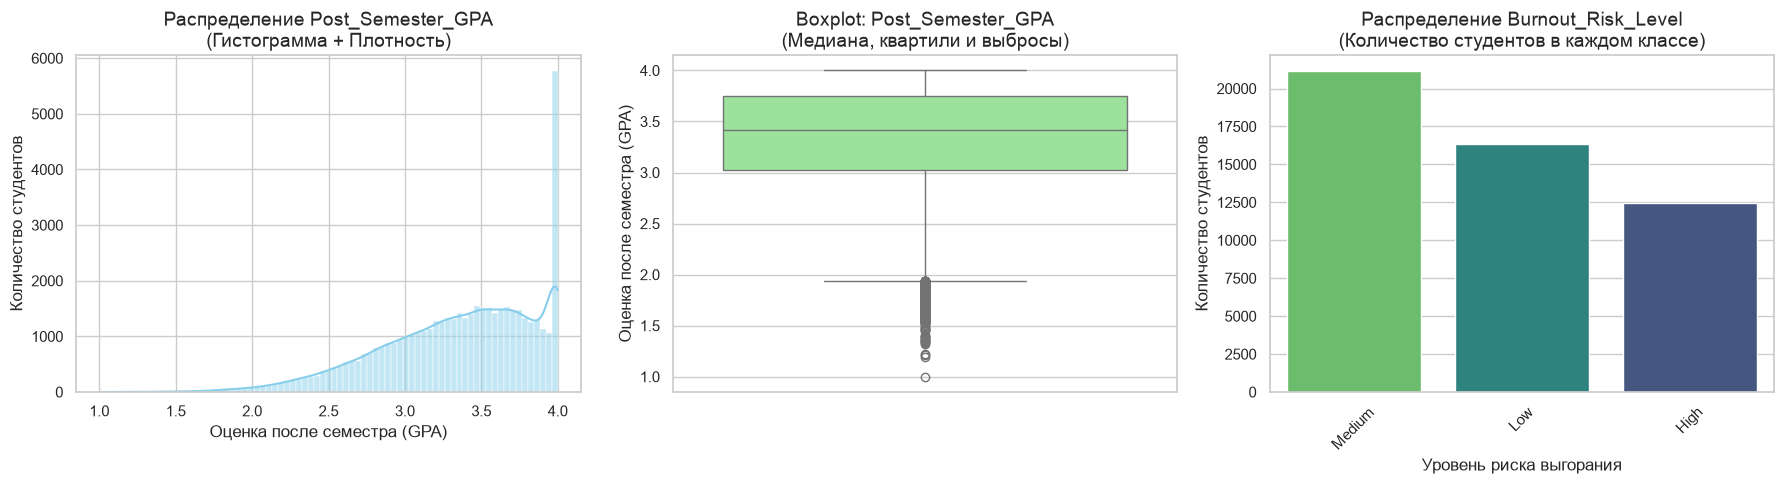

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=dataSet, x='Post_Semester_GPA', kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Распределение Post_Semester_GPA\n(Гистограмма + Плотность)', fontsize=14)
axes[0].set_xlabel('Оценка после семестра (GPA)', fontsize=12)
axes[0].set_ylabel('Количество студентов', fontsize=12)


sns.boxplot(data=dataSet, y='Post_Semester_GPA', color='lightgreen', ax=axes[1])
axes[1].set_title('Boxplot: Post_Semester_GPA\n(Медиана, квартили и выбросы)', fontsize=14)
axes[1].set_ylabel('Оценка после семестра (GPA)', fontsize=12)


sns.countplot(data=dataSet, x='Burnout_Risk_Level', hue='Burnout_Risk_Level', 
              palette='viridis', ax=axes[2], 
              order=dataSet['Burnout_Risk_Level'].value_counts().index, 
              legend=False)
axes[2].set_title('Распределение Burnout_Risk_Level\n(Количество студентов в каждом классе)', fontsize=14)
axes[2].set_xlabel('Уровень риска выгорания', fontsize=12)
axes[2].set_ylabel('Количество студентов', fontsize=12)

plt.setp(axes[2].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

Post_Semester_GPA:
 - Распределение не нормальное, есть выбросы
 - Нужно обработать выбросы

Burnout_Risk_Level:
 - Есть дисбаланс классов

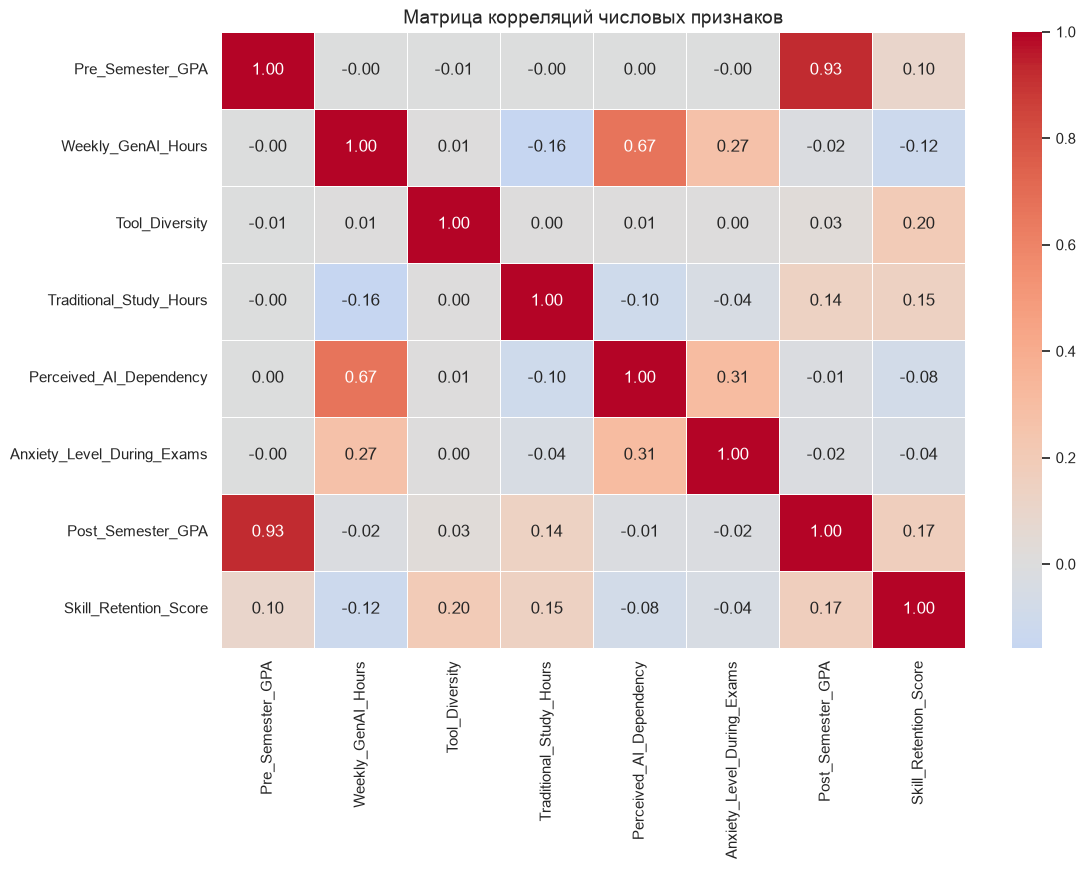

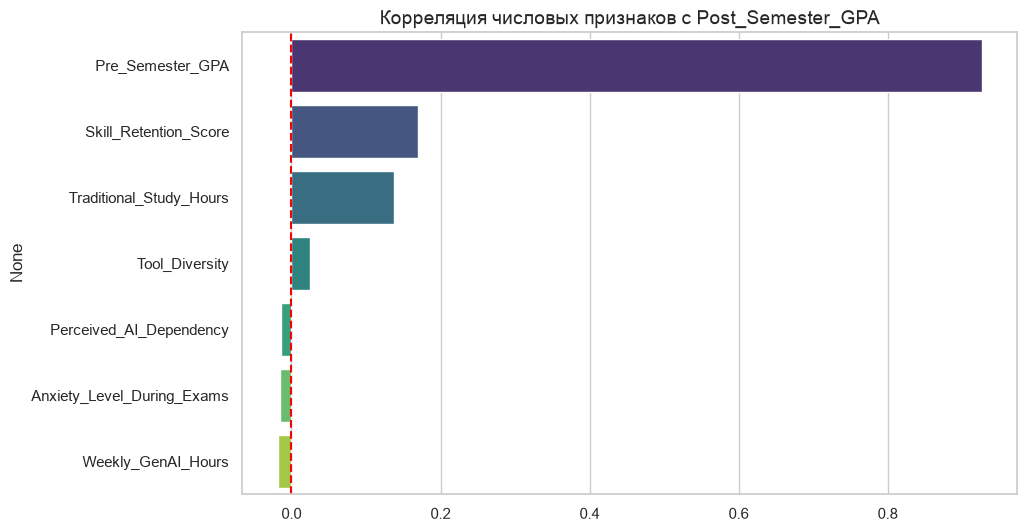

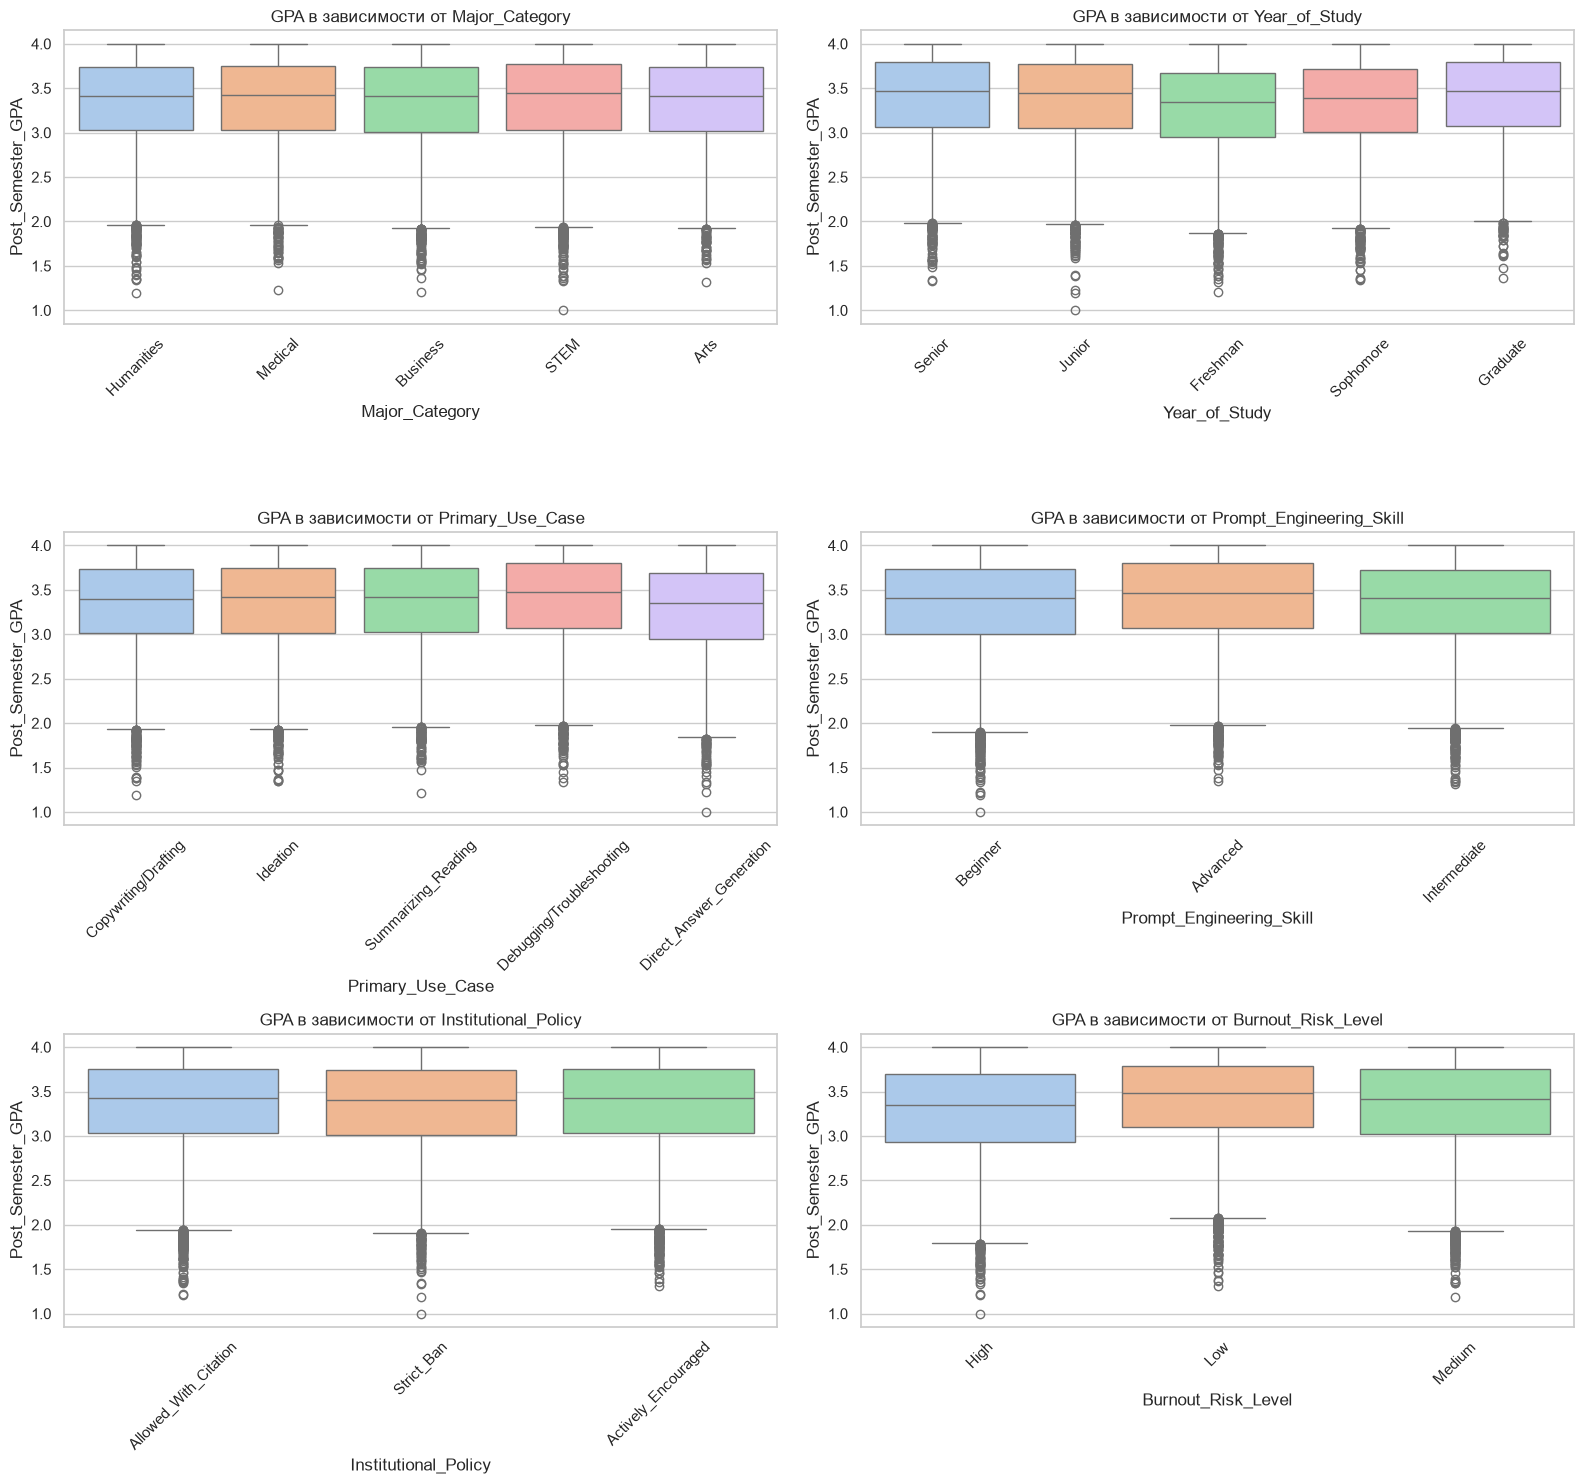

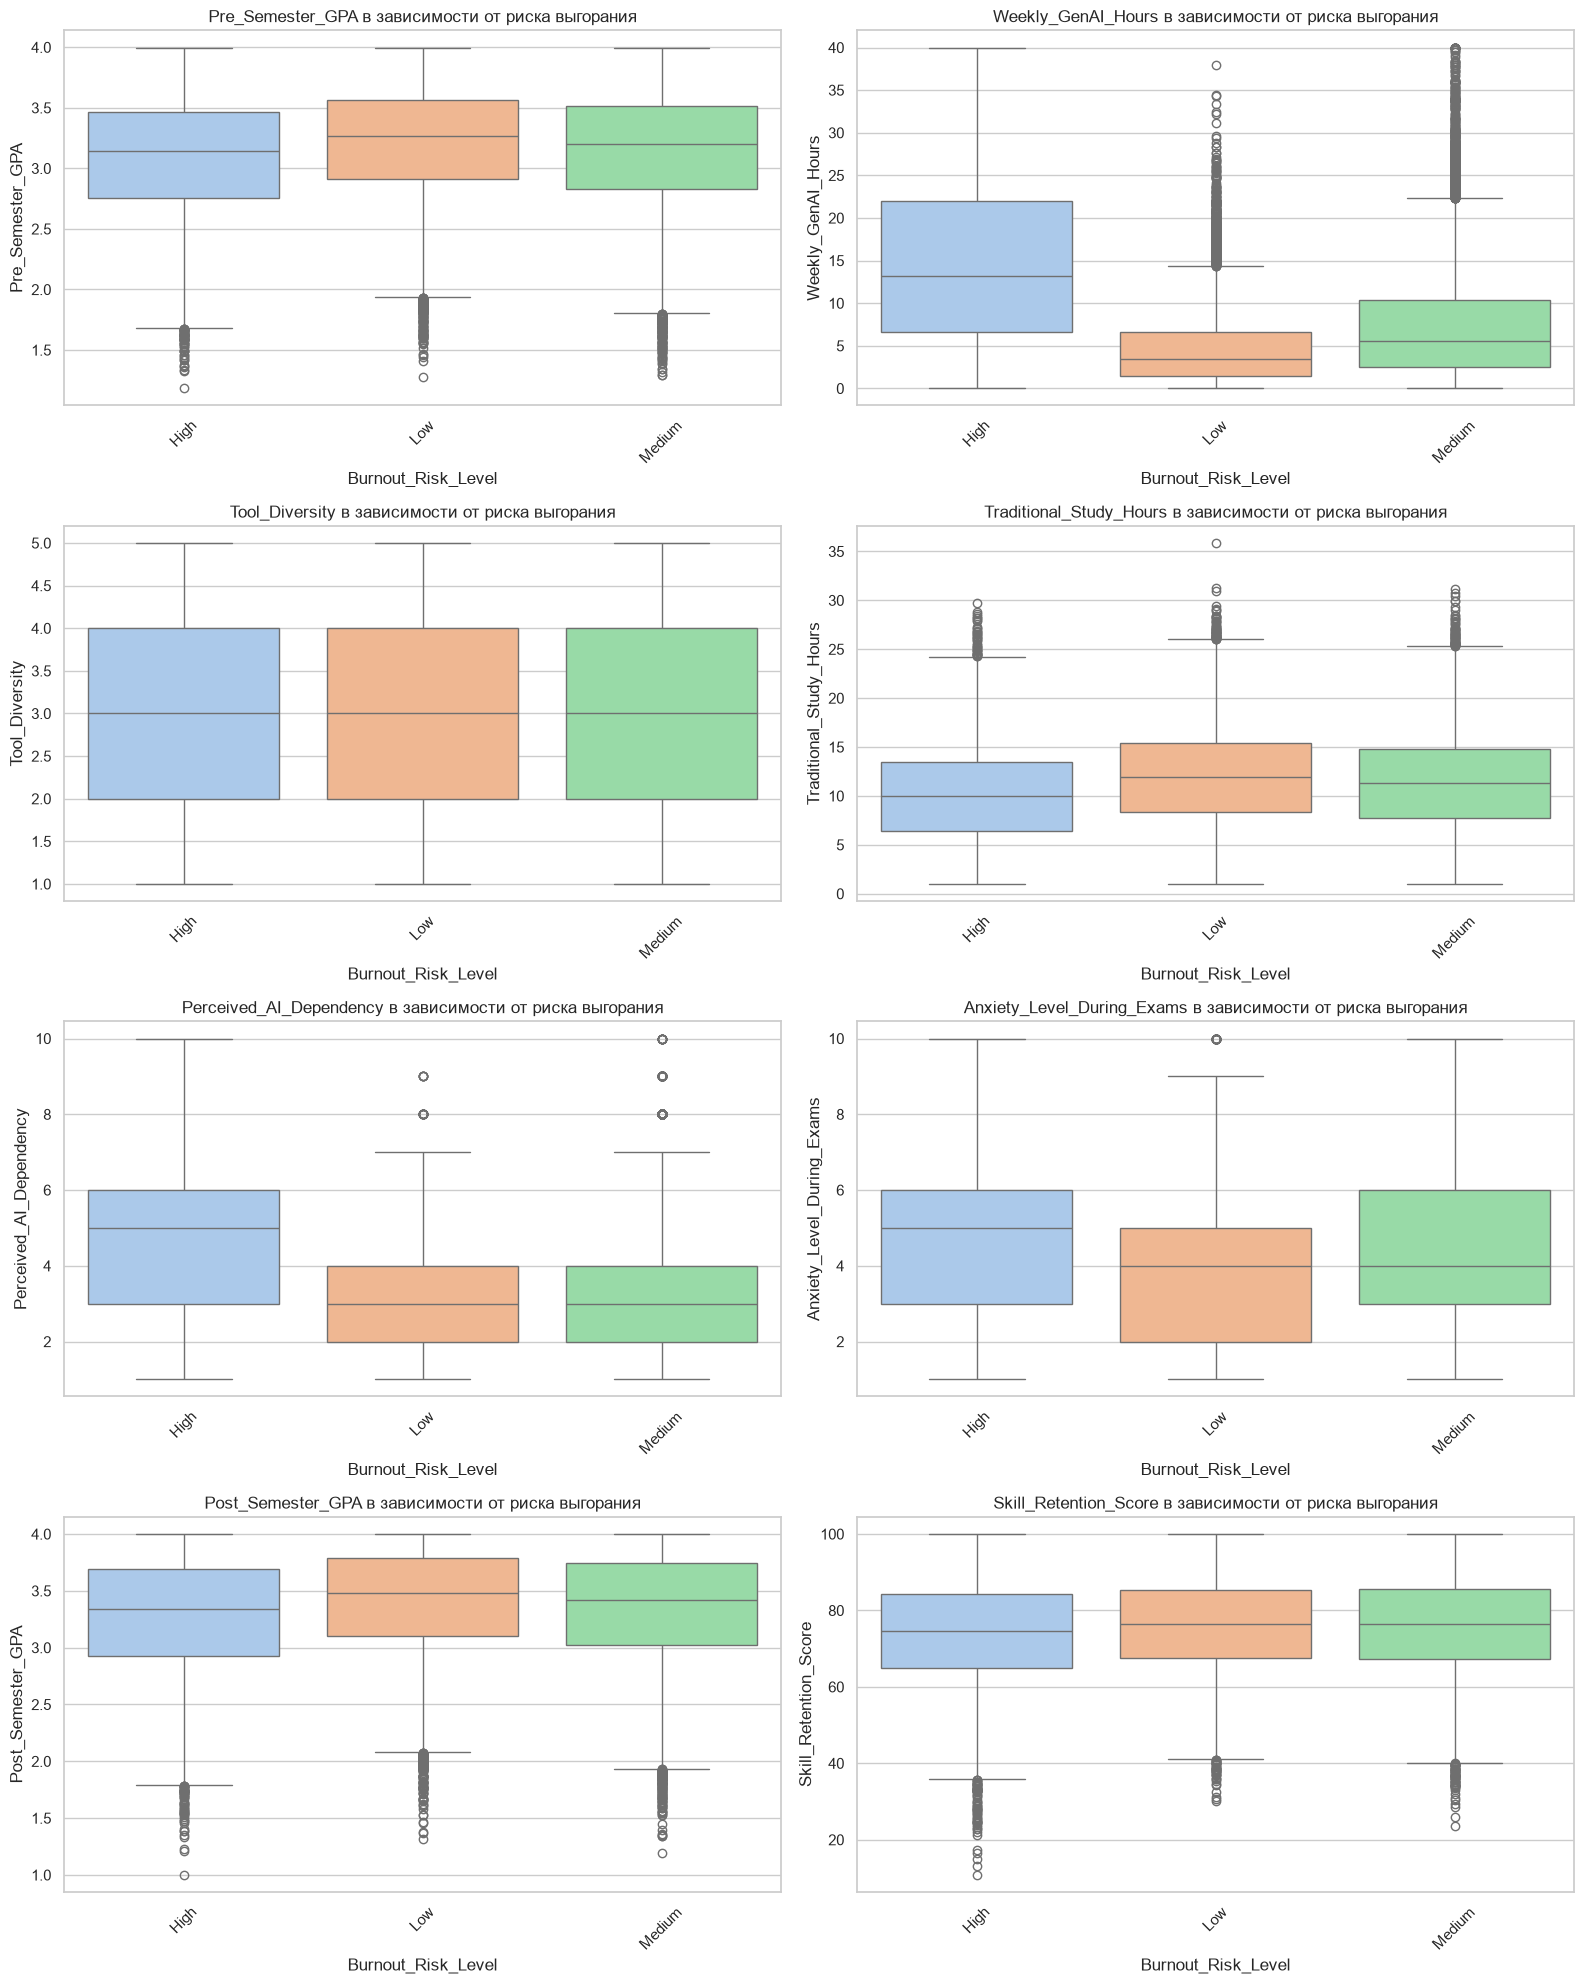

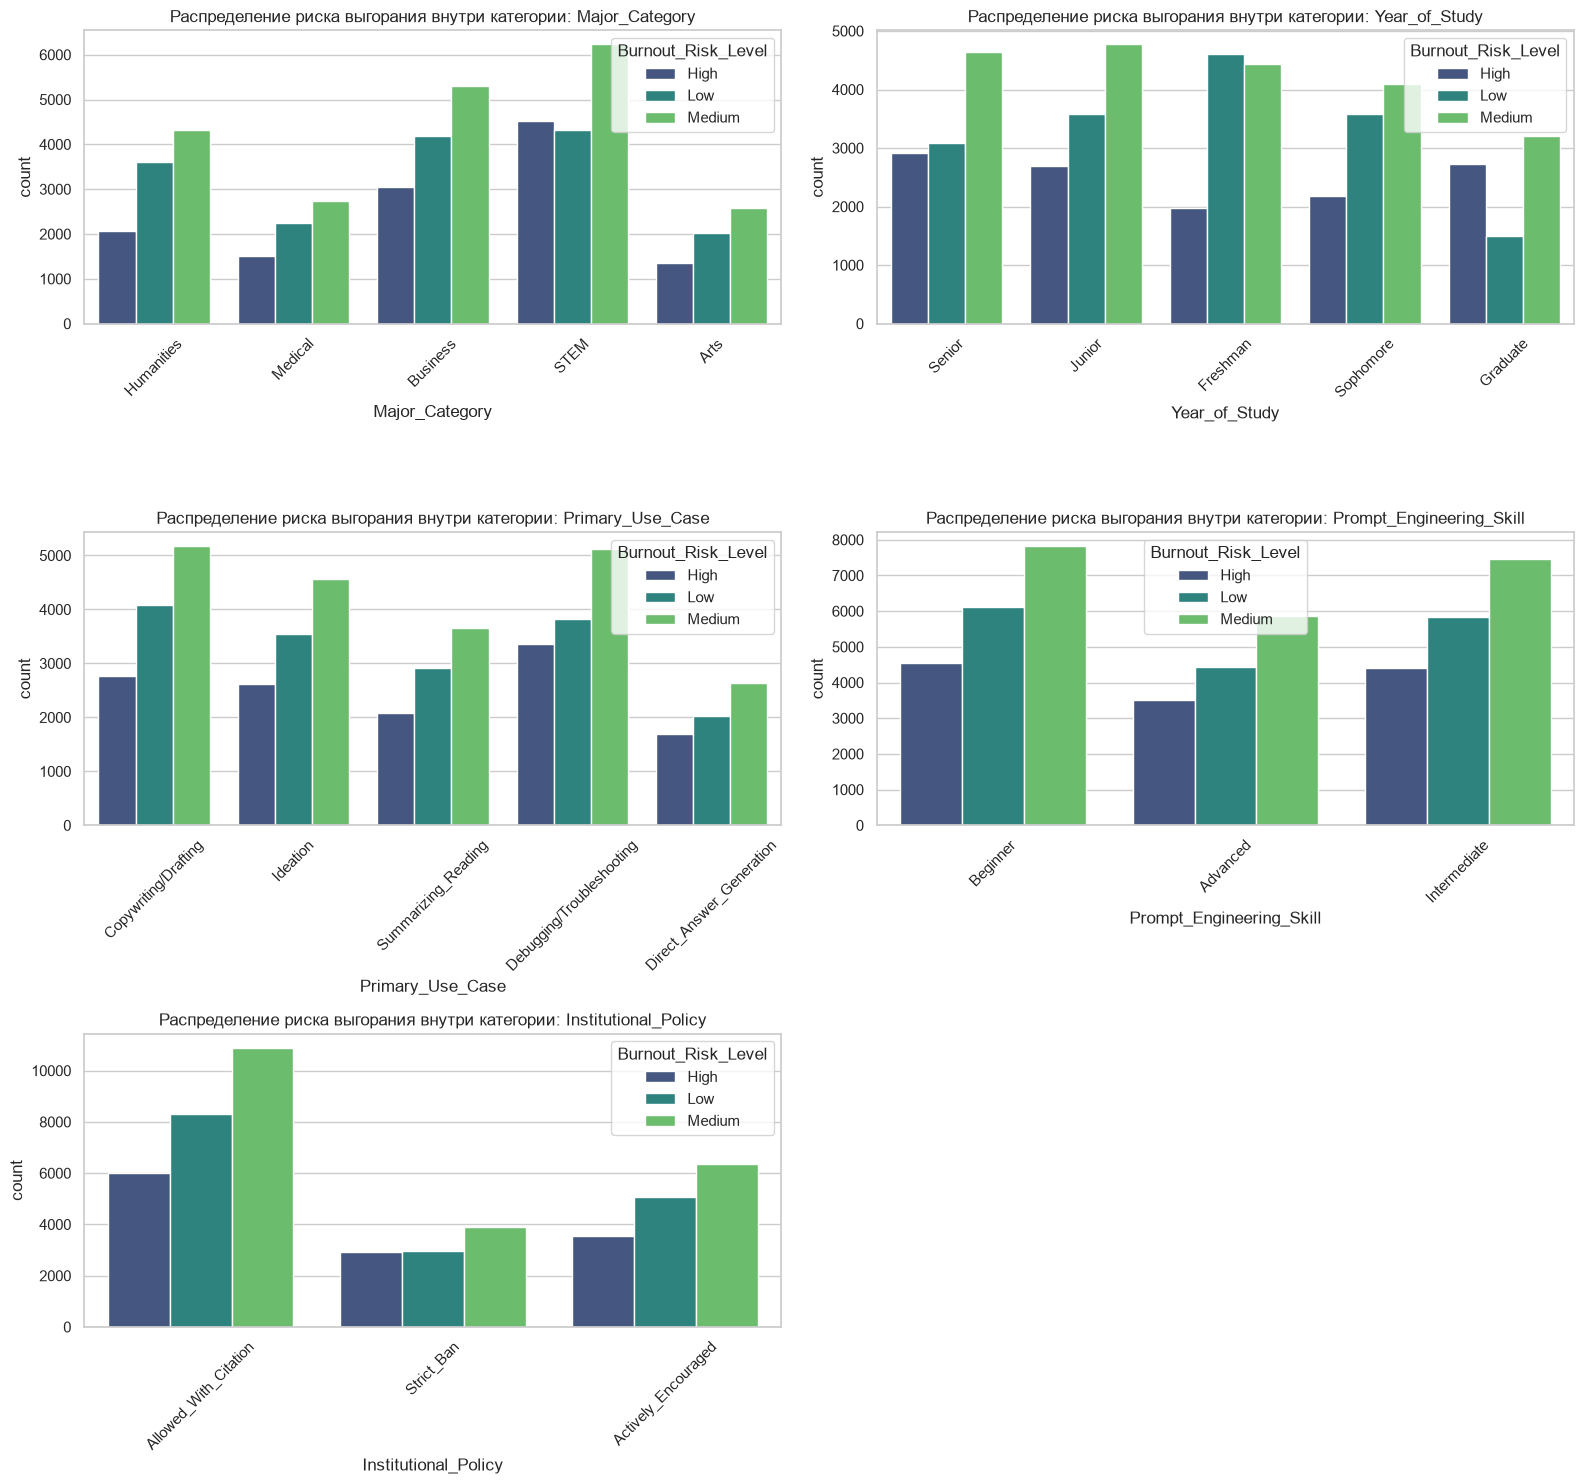

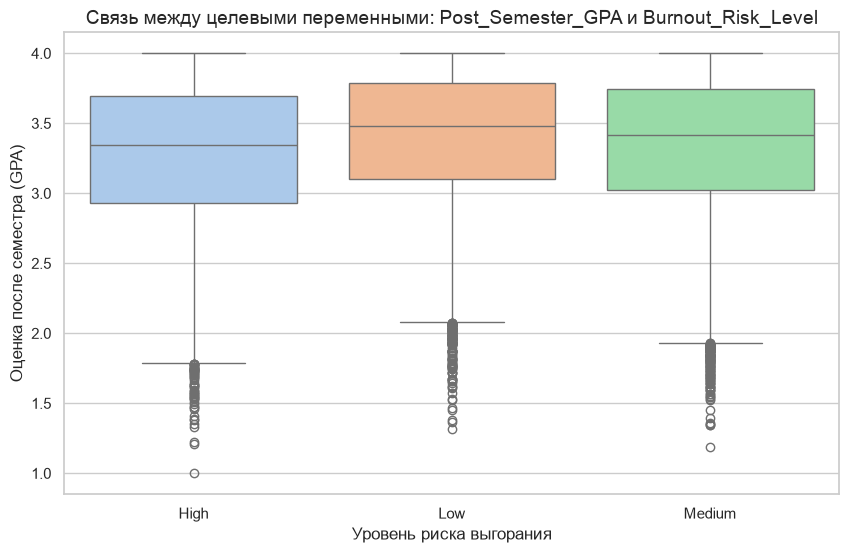

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid")

numeric_cols = dataSet.select_dtypes(include=[np.number]).drop(['Student_ID'], axis=1, errors='ignore').columns.tolist()
df_num = dataSet[numeric_cols]

# -------
plt.figure(figsize=(12, 8))
corr_matrix = df_num.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, center=0)
plt.title('Матрица корреляций числовых признаков', fontsize=14)
plt.show()
# -------


# -------
plt.figure(figsize=(10, 6))
corr_with_gpa = corr_matrix['Post_Semester_GPA'].drop('Post_Semester_GPA').sort_values(ascending=False)

sns.barplot(x=corr_with_gpa.values, y=corr_with_gpa.index, 
            hue=corr_with_gpa.index, palette='viridis', legend=False)
plt.title('Корреляция числовых признаков с Post_Semester_GPA', fontsize=14)
plt.axvline(0, color='red', linestyle='--') 
plt.show()
# ------


# ------
cat_cols_w_brl = dataSet.select_dtypes(include=['str', 'category', 'object']).columns.tolist()

n_cols = len(cat_cols_w_brl)
n_rows = (n_cols + 1) // 2

fig, axes = plt.subplots(n_rows, 2, figsize=(16, 5 * n_rows))
if n_rows == 1:
    axes = [axes]

for idx, col in enumerate(cat_cols_w_brl):
    row = idx // 2
    col_idx = idx % 2
    ax = axes[row][col_idx] if n_rows > 1 else axes[col_idx]
    
    sns.boxplot(data=dataSet, x=col, y='Post_Semester_GPA', 
                hue=col, palette='pastel', ax=ax, dodge=False, legend=False)
    ax.set_title(f'GPA в зависимости от {col}', fontsize=12)
    ax.tick_params(axis='x', rotation=45)

for idx in range(n_cols, n_rows * 2):
    row = idx // 2
    col_idx = idx % 2
    ax = axes[row][col_idx] if n_rows > 1 else axes[col_idx]
    ax.set_visible(False)

plt.tight_layout()
plt.show()

# -------

n_num = len(numeric_cols)
n_rows_num = (n_num + 1) // 2

fig_num, axes_num = plt.subplots(n_rows_num, 2, figsize=(16, 5 * n_rows_num))
axes_num = axes_num.flatten()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(data=dataSet, x='Burnout_Risk_Level', y=col, 
                hue='Burnout_Risk_Level', palette='pastel', ax=axes_num[idx], dodge=False, legend=False)
    axes_num[idx].set_title(f'{col} в зависимости от риска выгорания', fontsize=12)
    axes_num[idx].tick_params(axis='x', rotation=45)

for idx in range(n_num, len(axes_num)):
    axes_num[idx].set_visible(False)

plt.tight_layout()
plt.show()

cat_cols_wo_brl = dataSet.select_dtypes(include=['str', 'category']).drop(columns=['Burnout_Risk_Level'], errors='ignore').columns.tolist()

n_cat = len(cat_cols_wo_brl)
n_rows_cat = (n_cat + 1) // 2

fig_cat, axes_cat = plt.subplots(n_rows_cat, 2, figsize=(16, 5 * n_rows_cat))
axes_cat = axes_cat.flatten()

for idx, col in enumerate(cat_cols_wo_brl):
    sns.countplot(data=dataSet, x=col, hue='Burnout_Risk_Level', palette='viridis', ax=axes_cat[idx])
    axes_cat[idx].set_title(f'Распределение риска выгорания внутри категории: {col}', fontsize=12)
    axes_cat[idx].tick_params(axis='x', rotation=45)
    axes_cat[idx].legend(title='Burnout_Risk_Level')

for idx in range(n_cat, len(axes_cat)):
    axes_cat[idx].set_visible(False)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

sns.boxplot(data=dataSet, x='Burnout_Risk_Level', y='Post_Semester_GPA', 
            hue='Burnout_Risk_Level', palette='pastel', dodge=False, legend=False)

plt.title('Связь между целевыми переменными: Post_Semester_GPA и Burnout_Risk_Level', fontsize=14)
plt.xlabel('Уровень риска выгорания', fontsize=12)
plt.ylabel('Оценка после семестра (GPA)', fontsize=12)

plt.show()


# 2. Предобработка данных

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer

df = dataSet.copy()

# Пропусков в данных нет, но для возможности переиспользовать этот код с другим дата сетом выполним обработку данных

num_cols = df.select_dtypes(include=[np.number]).drop(columns=['Student_ID'], errors='ignore').columns.tolist()

print(f"Найдено числовых признаков для кодирования: {len(num_cols)}")
print(num_cols)

cat_cols = df.select_dtypes(include=['str', 'category', 'object', 'bool']).columns.tolist()

print(f"Найдено категориальных признаков для кодирования: {len(cat_cols)}")
print(cat_cols)


for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print(f"Размер данных после удаления выбросов IQR: {df.shape}")


df_trees = df.copy()
for col in cat_cols:
    df_trees[col] = LabelEncoder().fit_transform(df_trees[col].astype(str))

df_linear = pd.get_dummies(df, drop_first=True, dtype=int)

print(f"Размер датасета для деревьев: {df_trees.shape}")
print(f"Размер датасета для линейных моделей: {df_linear.shape}")

df['AI_Usage_Ratio'] = df['Weekly_GenAI_Hours'] / (df['Traditional_Study_Hours'] + 1e-5)
df['Total_Study_Hours'] = df['Weekly_GenAI_Hours'] + df['Traditional_Study_Hours']
df['AI_Efficiency'] = df['Pre_Semester_GPA'] * df['Weekly_GenAI_Hours']
df['GPA_Change'] = df['Post_Semester_GPA'] - df['Pre_Semester_GPA'] # !!!

df_trees['AI_Usage_Ratio'] = df['AI_Usage_Ratio']
df_trees['Total_Study_Hours'] = df['Total_Study_Hours']
df_trees['AI_Efficiency'] = df['AI_Efficiency']

df_linear['AI_Usage_Ratio'] = df['AI_Usage_Ratio']
df_linear['Total_Study_Hours'] = df['Total_Study_Hours']
df_linear['AI_Efficiency'] = df['AI_Efficiency']

print(f"Размер датасета для деревьев (после добавления новых признаков): {df_trees.shape}")
print(f"Размер датасета для линейных моделей (после добавления новых признаков): {df_linear.shape}")

Найдено числовых признаков для кодирования: 8
['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Tool_Diversity', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score']
Найдено категориальных признаков для кодирования: 7
['Major_Category', 'Year_of_Study', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Paid_Subscription', 'Institutional_Policy', 'Burnout_Risk_Level']
Размер данных после удаления выбросов IQR: (46355, 16)
Размер датасета для деревьев: (46355, 16)
Размер датасета для линейных моделей: (46355, 28)
Размер датасета для деревьев (после добавления новых признаков): (46355, 19)
Размер датасета для линейных моделей (после добавления новых признаков): (46355, 31)


# AI_Usage_Ratio = Weekly_GenAI_Hours / Traditional_Study_Hours
**Что отражает:** Баланс между временем, затрачиваемым на использование генеративного ИИ, и временем на традиционное обучение.

**Почему полезен для предсказания:**
- **Для Post_Semester_GPA:** Слишком высокое соотношение (много ИИ, мало традиционного обучения) может указывать на то, что студент делегирует ИИ понимание материала, а не использует его как помощника. Это может снижать глубину усвоения знаний и, как следствие, итоговые оценки. Умеренное соотношение, наоборот, может говорить об эффективном дополнении традиционных методов ИИ-инструментами.
- **Для Burnout_Risk_Level:** Высокая зависимость от ИИ (высокий AI_Usage_Ratio) может коррелировать с признаком Perceived_AI_Dependency и указывать на попытку студента «срезать углы» из-за перегрузки, что является косвенным маркером выгорания.


# Total_Study_Hours = Weekly_GenAI_Hours + Traditional_Study_Hours
**Что отражает:** Общее еженедельное время, которое студент уделяет учебному процессу (включая все его формы).

**Почему полезен для предсказания:**
- **Для Post_Semester_GPA:** В целом, больше времени на учебу → выше успеваемость (положительная корреляция). Однако после определенного порога может наступать эффект «переутомления», когда дополнительные часы не дают прироста в GPA. Модель (особенно нелинейная, вроде Random Forest) сможет уловить эту нелинейность.
- **Для Burnout_Risk_Level:** Это один из самых прямых предикторов выгорания. Чрезмерная учебная нагрузка — классический фактор академического выгорания. Признак поможет модели четко разделять студентов с высоким и низким риском.


# AI_Efficiency = Pre_Semester_GPA * Weekly_GenAI_Hours
**Что отражает:** Взаимодействие (interaction feature) между базовым уровнем знаний студента и интенсивностью использования им ИИ. Это синтетический признак, показывающий «потенциал продуктивного использования ИИ».

**Почему полезен для предсказания:**
- **Для Post_Semester_GPA:** Одинаковое количество часов использования ИИ (Weekly_GenAI_Hours) может давать разный результат для студентов с разным начальным уровнем (Pre_Semester_GPA). Студент с высоким базовым GPA, скорее всего, использует ИИ для углубления знаний и решения сложных задач (высокий AI_Efficiency → высокий итоговый GPA). Студент с низким базовым GPA может использовать ИИ для списывания или получения готовых ответов без понимания (низкая реальная эффективность). Линейные модели не умеют сами находить взаимодействия признаков, поэтому создание такого признака вручную критически важно для них.
- **Для Burnout_Risk_Level:** Студенты с высоким Pre_Semester_GPA, которые при этом тратят много часов на ИИ, могут находиться в состоянии «перфекционизма» или чрезмерной самоотдачи, что является фактором риска выгорания.



Linear Regression (Scaled)          | R2: 0.8935 | MSE: 0.0243 | RMSE: 0.1557 | MAE: 0.1236


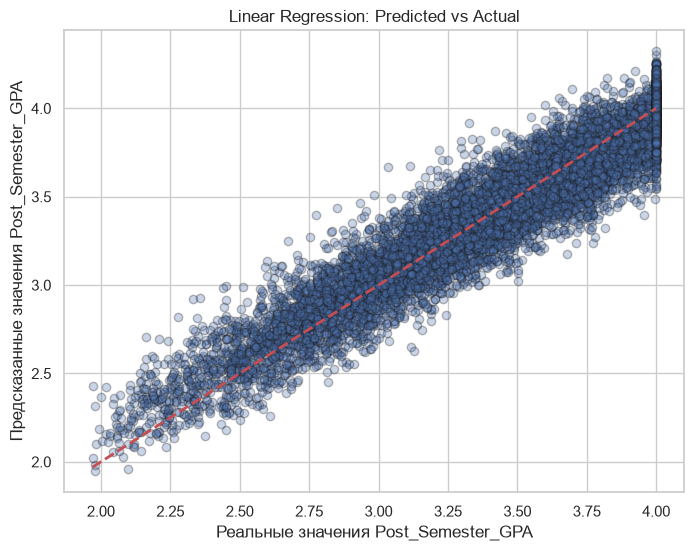

Linear Regression (Poly Degree 2)   | R2: 0.9038 | MSE: 0.0219 | RMSE: 0.1480 | MAE: 0.1177
KNN Regressor (Best k=12)           | R2: 0.6238 | MSE: 0.0856 | RMSE: 0.2927 | MAE: 0.2394


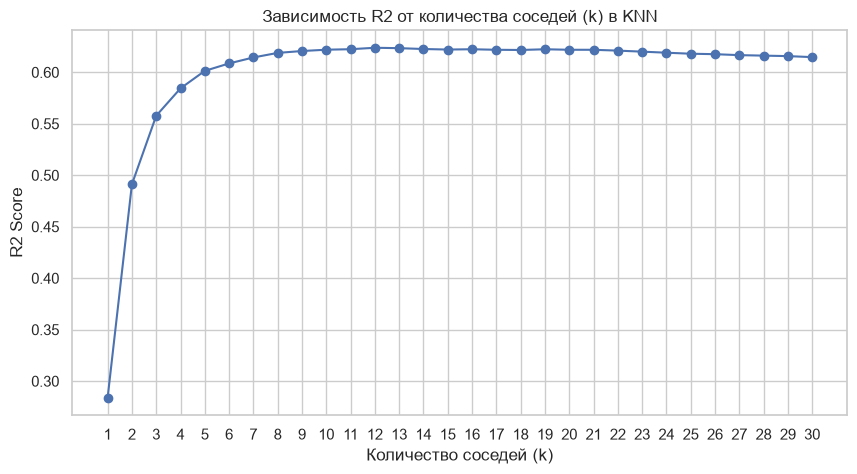

Decision Tree Regressor (max_depth=5) | R2: 0.8673 | MSE: 0.0302 | RMSE: 0.1738 | MAE: 0.1363
Random Forest Regressor (n_estimators=100) | R2: 0.8931 | MSE: 0.0243 | RMSE: 0.1560 | MAE: 0.1218

ИТОГОВОЕ СРАВНЕНИЕ МЕТРИК РЕГРЕССИИ (отсортировано по R2)


,Model,R2,MSE,RMSE,MAE
0,Linear Regression (Poly Degree 2),0.9038,0.0219,0.1480,0.1177
1,Linear Regression (Scaled),0.8935,0.0243,0.1557,0.1236
2,Random Forest Regressor (n_estimators=100),0.8931,0.0243,0.1560,0.1218
3,Decision Tree Regressor (max_depth=5),0.8673,0.0302,0.1738,0.1363
4,KNN Regressor (Best k=12),0.6238,0.0856,0.2927,0.2394


Random Forest (GridSearchCV: {'max_depth': 10, 'n_estimators': 200}) | R2: 0.8943 | MSE: 0.0241 | RMSE: 0.1551 | MAE: 0.1210


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

y = df['Post_Semester_GPA']

features_to_drop = ['Student_ID', 'Post_Semester_GPA', 'Burnout_Risk_Level', 'GPA_Change']

X_linear = df_linear.drop(columns=[col for col in features_to_drop if col in df_linear.columns])
X_trees = df_trees.drop(columns=[col for col in features_to_drop if col in df_trees.columns])

X_train_l, X_test_l, y_train, y_test = train_test_split(X_linear, y, test_size=0.2, random_state=42)
X_train_t, X_test_t, _, _ = train_test_split(X_trees, y, test_size=0.2, random_state=42) # y тот же самый

scaler = StandardScaler()
X_train_l_scaled = scaler.fit_transform(X_train_l)
X_test_l_scaled = scaler.transform(X_test_l)

results = []
def evaluate_and_store(y_true, y_pred, model_name):
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    results.append({
        'Model': model_name,
        'R2': round(r2, 4),
        'MSE': round(mse, 4),
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4)
    })
    print(f"{model_name:<35} | R2: {r2:.4f} | MSE: {mse:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")

lr = LinearRegression()
lr.fit(X_train_l_scaled, y_train)
y_pred_lr = lr.predict(X_test_l_scaled)
evaluate_and_store(y_test, y_pred_lr, "Linear Regression (Scaled)")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.3, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Реальные значения Post_Semester_GPA')
plt.ylabel('Предсказанные значения Post_Semester_GPA')
plt.title('Linear Regression: Predicted vs Actual')
plt.grid(True)
plt.show()

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_l_scaled)
X_test_poly = poly.transform(X_test_l_scaled)

lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)
y_pred_lr_poly = lr_poly.predict(X_test_poly)
evaluate_and_store(y_test, y_pred_lr_poly, "Linear Regression (Poly Degree 2)")

k_values = range(1, 31)
r2_scores_knn = []
best_knn_model = None
best_r2_knn = -np.inf

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_l_scaled, y_train)
    y_pred_knn = knn.predict(X_test_l_scaled)
    current_r2 = r2_score(y_test, y_pred_knn)
    r2_scores_knn.append(current_r2)
    
    if current_r2 > best_r2_knn:
        best_r2_knn = current_r2
        best_knn_model = knn

y_pred_best_knn = best_knn_model.predict(X_test_l_scaled)
evaluate_and_store(y_test, y_pred_best_knn, f"KNN Regressor (Best k={best_knn_model.n_neighbors})")

plt.figure(figsize=(10, 5))
plt.plot(k_values, r2_scores_knn, marker='o', linestyle='-', color='b')
plt.xlabel('Количество соседей (k)')
plt.ylabel('R2 Score')
plt.title('Зависимость R2 от количества соседей (k) в KNN')
plt.xticks(k_values)
plt.grid(True)
plt.show()

dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train_t, y_train)
y_pred_dt = dt.predict(X_test_t)
evaluate_and_store(y_test, y_pred_dt, "Decision Tree Regressor (max_depth=5)")

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_t, y_train)
y_pred_rf = rf.predict(X_test_t)
evaluate_and_store(y_test, y_pred_rf, "Random Forest Regressor (n_estimators=100)")

results_df = pd.DataFrame(results)
display(results_df.sort_values(by='R2', ascending=False).reset_index(drop=True))

# -----

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None]
}
grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
grid_rf.fit(X_train_t, y_train)
y_pred_grid_rf = grid_rf.predict(X_test_t)
best_params = grid_rf.best_params_
evaluate_and_store(y_test, y_pred_grid_rf, f"Random Forest (GridSearchCV: {best_params})")


Размер обучающей выборки: (37084, 16)
Размер тестовой выборки: (9271, 16)
Распределение классов в train:
Burnout_Risk_Level
Medium    16297
Low       12886
High       7901
Name: count, dtype: int64
Модель: Decision Tree (max_depth=4)
Accuracy: 0.5067



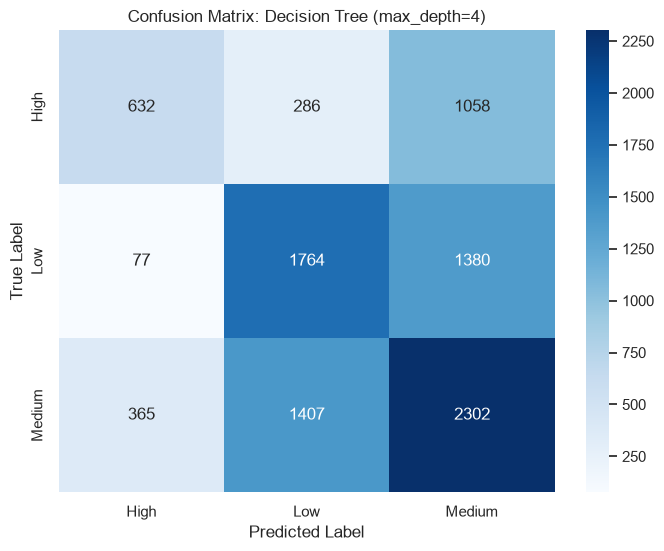

Classification Report:
              precision    recall  f1-score   support

        High       0.59      0.32      0.41      1976
         Low       0.51      0.55      0.53      3221
      Medium       0.49      0.57      0.52      4074

    accuracy                           0.51      9271
   macro avg       0.53      0.48      0.49      9271
weighted avg       0.52      0.51      0.50      9271

Модель: Random Forest (n_estimators=100)
Accuracy: 0.4961



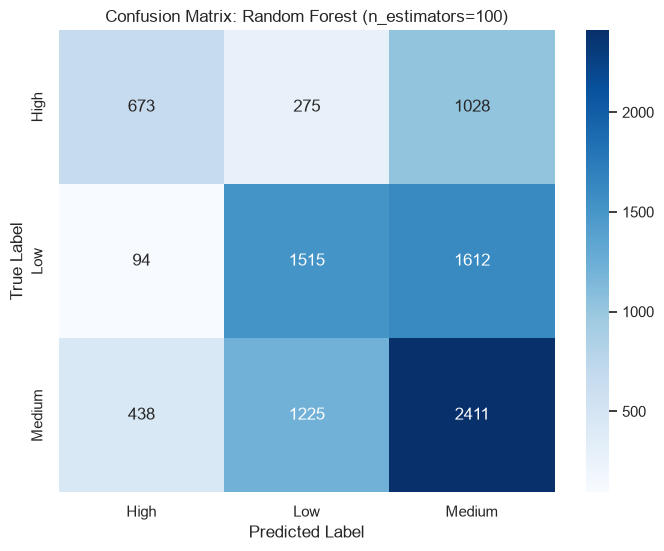

Classification Report:
              precision    recall  f1-score   support

        High       0.56      0.34      0.42      1976
         Low       0.50      0.47      0.49      3221
      Medium       0.48      0.59      0.53      4074

    accuracy                           0.50      9271
   macro avg       0.51      0.47      0.48      9271
weighted avg       0.50      0.50      0.49      9271


--- Decision Tree (БЕЗ балансировки) ---
Accuracy: 0.5067
              precision    recall  f1-score   support

        High       0.59      0.32      0.41      1976
         Low       0.51      0.55      0.53      3221
      Medium       0.49      0.57      0.52      4074

    accuracy                           0.51      9271
   macro avg       0.53      0.48      0.49      9271
weighted avg       0.52      0.51      0.50      9271


--- Decision Tree (С class_weight='balanced') ---
Accuracy: 0.4149
              precision    recall  f1-score   support

        High       0.35      0.37

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_clf = df['Burnout_Risk_Level']

features_to_drop_clf = ['Student_ID', 'Post_Semester_GPA', 'Burnout_Risk_Level', 'GPA_Change']

X_clf = df_trees.drop(columns=[col for col in features_to_drop_clf if col in df_trees.columns])

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f"Размер обучающей выборки: {X_train_clf.shape}")
print(f"Размер тестовой выборки: {X_test_clf.shape}")
print(f"Распределение классов в train:\n{y_train_clf.value_counts()}")

dt_clf = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_clf.fit(X_train_clf, y_train_clf)
y_pred_dt_clf = dt_clf.predict(X_test_clf)

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_clf, y_train_clf)
y_pred_rf_clf = rf_clf.predict(X_test_clf)

def evaluate_classification(y_true, y_pred, model_name, classes):
    print(f"{'='*60}")
    print(f"Модель: {model_name}")
    print(f"{'='*60}")
    
    accuracy = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {accuracy:.4f}\n")
    
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix: {model_name}')
    plt.show()

    print("Classification Report:")
    print(classification_report(y_true, y_pred, labels=classes))

classes = sorted(df['Burnout_Risk_Level'].unique())

evaluate_classification(y_test_clf, y_pred_dt_clf, "Decision Tree (max_depth=4)", classes)

evaluate_classification(y_test_clf, y_pred_rf_clf, "Random Forest (n_estimators=100)", classes)



# Попробуем улучшить показатели классификации

dt_balanced = DecisionTreeClassifier(
    class_weight='balanced', 
    random_state=42
)
dt_balanced.fit(X_train_clf, y_train_clf)
y_pred_dt_balanced = dt_balanced.predict(X_test_clf)

rf_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf_balanced.fit(X_train_clf, y_train_clf)
y_pred_rf_balanced = rf_balanced.predict(X_test_clf)

print("\n--- Decision Tree (БЕЗ балансировки) ---")
print(f"Accuracy: {accuracy_score(y_test_clf, y_pred_dt_clf):.4f}")
print(classification_report(y_test_clf, y_pred_dt_clf))

print("\n--- Decision Tree (С class_weight='balanced') ---")
print(f"Accuracy: {accuracy_score(y_test_clf, y_pred_dt_balanced):.4f}")
print(classification_report(y_test_clf, y_pred_dt_balanced))

print("\n--- Random Forest (БЕЗ балансировки) ---")
print(f"Accuracy: {accuracy_score(y_test_clf, y_pred_rf_clf):.4f}")
print(classification_report(y_test_clf, y_pred_rf_clf))

print("\n--- Random Forest (С class_weight='balanced') ---")
print(f"Accuracy: {accuracy_score(y_test_clf, y_pred_rf_balanced):.4f}")
print(classification_report(y_test_clf, y_pred_rf_balanced))

Сильно улучшить не получилос. Возможно требуется применение других методов

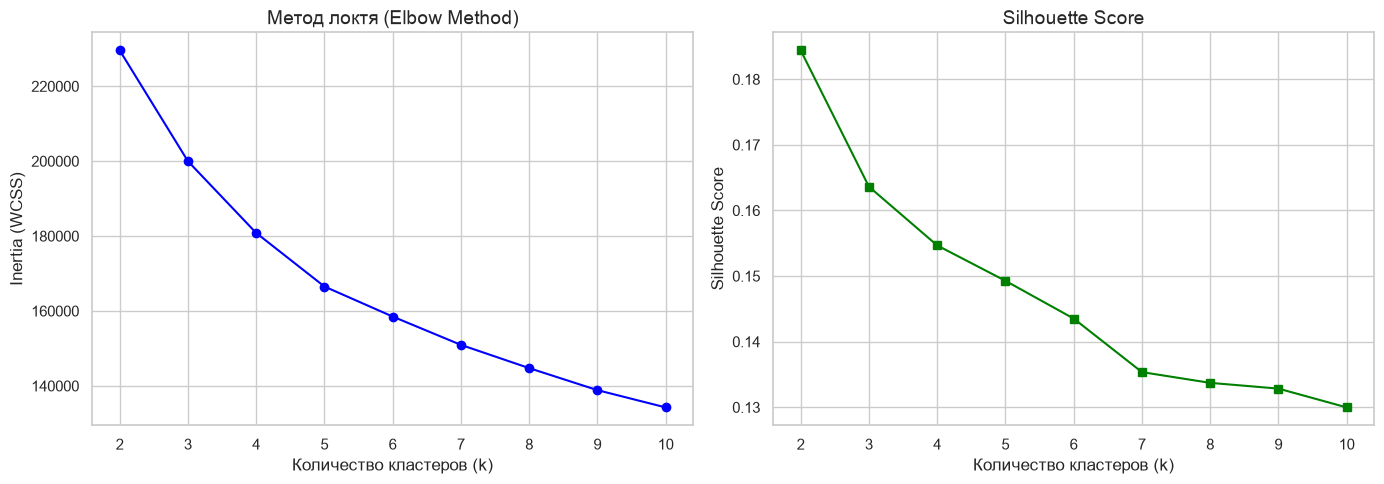


Оптимальное количество кластеров по Silhouette Score: 2
Silhouette Score: 0.1844

Размер каждого кластера:
Cluster
0    15069
1    31286
Name: count, dtype: int64


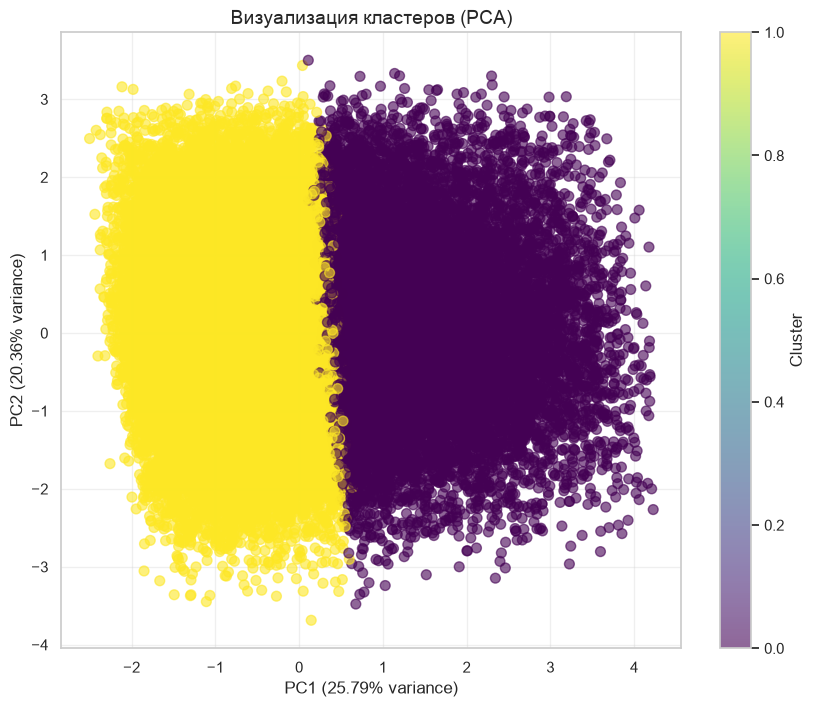

БЕЗ кластера: R2 = 0.8931, MSE = 0.0243
С кластером:  R2 = 0.8933, MSE = 0.0243
БЕЗ кластера: Accuracy = 0.4961
С кластером:  Accuracy = 0.4916

Classification Report (С кластером):
              precision    recall  f1-score   support

        High       0.56      0.34      0.42      1976
         Low       0.49      0.47      0.48      3221
      Medium       0.47      0.58      0.52      4074

    accuracy                           0.49      9271
   macro avg       0.51      0.46      0.48      9271
weighted avg       0.50      0.49      0.49      9271



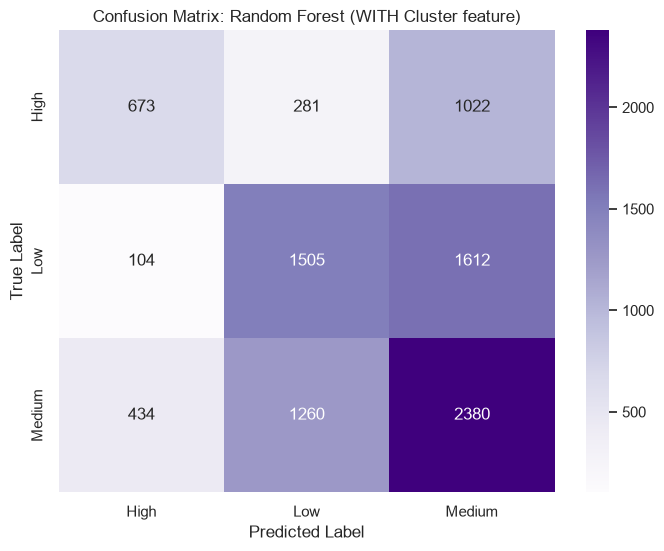

In [7]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cluster_features = [
    'Weekly_GenAI_Hours',
    'Traditional_Study_Hours',
    'Pre_Semester_GPA',
    'Skill_Retention_Score',
    'Prompt_Engineering_Skill',
    'Perceived_AI_Dependency'
]

X_cluster = df_trees[cluster_features].copy()

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

k_range = range(2, 11)
inertia = []
silhouette_scores = []

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_cluster_scaled)
    inertia.append(kmeans_temp.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster_scaled, kmeans_temp.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertia, marker='o', linestyle='-', color='blue')
ax1.set_xlabel('Количество кластеров (k)', fontsize=12)
ax1.set_ylabel('Inertia (WCSS)', fontsize=12)
ax1.set_title('Метод локтя (Elbow Method)', fontsize=14)
ax1.set_xticks(k_range)
ax1.grid(True)

ax2.plot(k_range, silhouette_scores, marker='s', linestyle='-', color='green')
ax2.set_xlabel('Количество кластеров (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score', fontsize=14)
ax2.set_xticks(k_range)
ax2.grid(True)

plt.tight_layout()
plt.show()

optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"\nОптимальное количество кластеров по Silhouette Score: {optimal_k}")
print(f"Silhouette Score: {max(silhouette_scores):.4f}")

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_cluster_scaled)

print(f"\nРазмер каждого кластера:")
print(df['Cluster'].value_counts().sort_index())

pca = PCA(n_components=2)
X_cluster_pca = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_cluster_pca[:, 0], X_cluster_pca[:, 1], 
                      c=df['Cluster'], cmap='viridis', alpha=0.6, s=50)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
plt.title('Визуализация кластеров (PCA)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, classification_report, confusion_matrix

features_to_drop = ['Student_ID', 'Post_Semester_GPA', 'Burnout_Risk_Level', 'GPA_Change']


X_trees_cluster = df_trees.copy()
X_trees_cluster['Cluster'] = df['Cluster']

X_reg_cluster = X_trees_cluster.drop(columns=[col for col in features_to_drop if col in X_trees_cluster.columns])
y_reg = df['Post_Semester_GPA']

X_train_reg_c, X_test_reg_c, y_train_reg_c, y_test_reg_c = train_test_split(
    X_reg_cluster, y_reg, test_size=0.2, random_state=42
)

rf_reg_cluster = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg_cluster.fit(X_train_reg_c, y_train_reg_c)
y_pred_rf_reg_cluster = rf_reg_cluster.predict(X_test_reg_c)

X_clf_cluster = df_trees.copy()
X_clf_cluster['Cluster'] = df['Cluster']

X_clf_data_cluster = X_clf_cluster.drop(columns=[col for col in features_to_drop if col in X_clf_cluster.columns])
y_clf_data = df['Burnout_Risk_Level']

X_train_clf_c, X_test_clf_c, y_train_clf_c, y_test_clf_c = train_test_split(
    X_clf_data_cluster, y_clf_data, test_size=0.2, random_state=42, stratify=y_clf_data
)

rf_clf_cluster = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf_cluster.fit(X_train_clf_c, y_train_clf_c)
y_pred_rf_clf_cluster = rf_clf_cluster.predict(X_test_clf_c)

base_rf_reg_r2 = results_df[results_df['Model'] == 'Random Forest Regressor (n_estimators=100)']['R2'].iloc[0]
base_rf_reg_mse = results_df[results_df['Model'] == 'Random Forest Regressor (n_estimators=100)']['MSE'].iloc[0]

print(f"БЕЗ кластера: R2 = {base_rf_reg_r2:.4f}, MSE = {base_rf_reg_mse:.4f}")
print(f"С кластером:  R2 = {r2_score(y_test_reg_c, y_pred_rf_reg_cluster):.4f}, "
      f"MSE = {mean_squared_error(y_test_reg_c, y_pred_rf_reg_cluster):.4f}")

print(f"БЕЗ кластера: Accuracy = {accuracy_score(y_test_clf, y_pred_rf_clf):.4f}")
print(f"С кластером:  Accuracy = {accuracy_score(y_test_clf_c, y_pred_rf_clf_cluster):.4f}")

classes = sorted(df['Burnout_Risk_Level'].unique())
print(f"\nClassification Report (С кластером):")
print(classification_report(y_test_clf_c, y_pred_rf_clf_cluster, labels=classes))


plt.figure(figsize=(8, 6))
cm_cluster = confusion_matrix(y_test_clf_c, y_pred_rf_clf_cluster, labels=classes)
sns.heatmap(cm_cluster, annot=True, fmt='d', cmap='Purples', 
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Random Forest (WITH Cluster feature)')
plt.show()